In [77]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PowerTransformer
from sklearn.compose import ColumnTransformer

### Conjunto de datos utilizado ###

Vínculo al dataset **Electricity Consumption Based on Weather Data** en Kaggle:

https://www.kaggle.com/datasets/sudhirsingh27/electricity-consumption-based-on-weather-data

In [78]:
data = pd.read_csv('data.csv')
data

,date,AWND,PRCP,TMAX,TMIN,daily_consumption
0,2006-12-16,2.5,0.0,10.6,5.0,1209.176
1,2006-12-17,2.6,0.0,13.3,5.6,3390.460
2,2006-12-18,2.4,0.0,15.0,6.7,2203.826
3,2006-12-19,2.4,0.0,7.2,2.2,1666.194
4,2006-12-20,2.4,0.0,7.2,1.1,2225.748
...,...,...,...,...,...,...
1428,2010-11-22,2.7,0.0,18.3,7.2,2041.536
1429,2010-11-23,3.1,0.0,16.1,10.0,1577.536
1430,2010-11-24,4.3,0.0,10.0,5.0,1796.248
1431,2010-11-25,1.6,1.5,7.8,3.9,1431.164


# Problema a resolver:
Dado condiciones meteorológicas, ¿cuál sera el valor de electricidad consumida de una casa individual?

Los datos fueron capturados durante el transcurso de 4 años (2006 - 2010) y los datos fueron obtenidos a base del conjunto de datos *Individual Household Electric Power Consumption*. La información del clima fue obtenida de *NOAA GHCN-Daily*.

El objetivo de este ejercicio es poder predecir el consumo cotidiano de energía eléctrica basado en factores climatológicos utilizando regresión lineal y pre-procesamiento de datos con un Pipeline.

In [79]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1433 entries, 0 to 1432
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   date               1433 non-null   object 
 1   AWND               1418 non-null   float64
 2   PRCP               1433 non-null   float64
 3   TMAX               1433 non-null   float64
 4   TMIN               1433 non-null   float64
 5   daily_consumption  1433 non-null   float64
dtypes: float64(5), object(1)
memory usage: 67.3+ KB


In [80]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
AWND,1418.0,2.642313,1.140021,0.000,1.8,2.40,3.300,10.200
PRCP,1433.0,3.800488,10.973436,0.000,0.0,0.00,1.300,192.300
TMAX,1433.0,17.187509,10.136415,-8.900,8.9,17.80,26.100,39.400
TMIN,1433.0,9.141242,9.028417,-14.400,2.2,9.40,17.200,27.200
daily_consumption,1433.0,1561.078061,606.819667,14.218,1165.7,1542.65,1893.608,4773.386


# Descripción de características

En este conjunto de datos poseemos 5 filas:
- AWND (Average daily wind speed): Toma en cuenta el promedio de la velocidad del viento en un día
- PRCP (Daily precipitation): Toma en cuenta la precipitación del día, en milímetros (mm).
- TMAX (Daily Maximum Temperature): Describe la temperatura más alta del día, en °C.
- TMIN (Daily Minimum Temperature): Describe la temperatura más baja del día, en °C.
- daily_consumption: Describe el consumo de electricidad en el día.

Todos los valores son numéricos, por lo cual el problema se trata de regresión; utilizar las características meteorológicas para predecir el consumo de electricidad.

# Visualización de datos

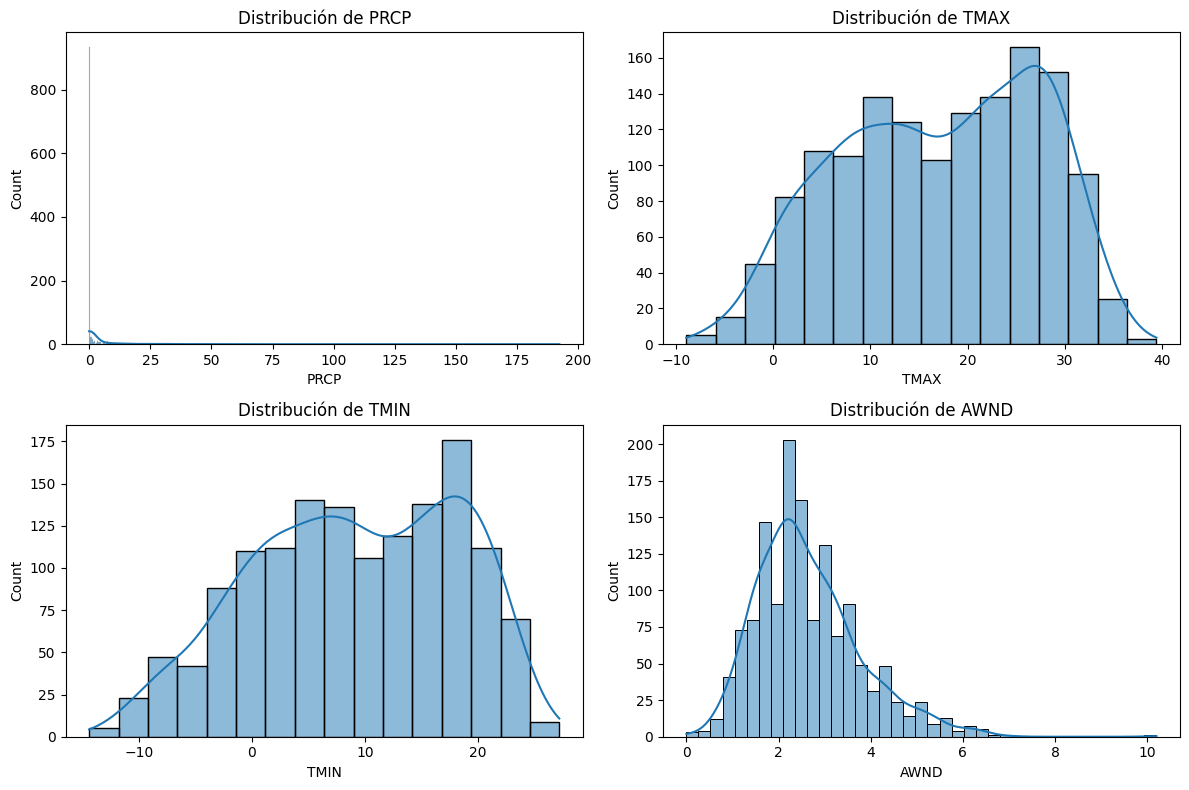

In [94]:
numerical_cols = ['PRCP', 'TMAX', 'TMIN', 'AWND']

fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(12, 8))

for ax, col in zip(axs.ravel(), numerical_cols):
    sns.histplot(data[col], kde=True, ax=ax)
    ax.set_title(f'Distribución de {col}')

fig.tight_layout()

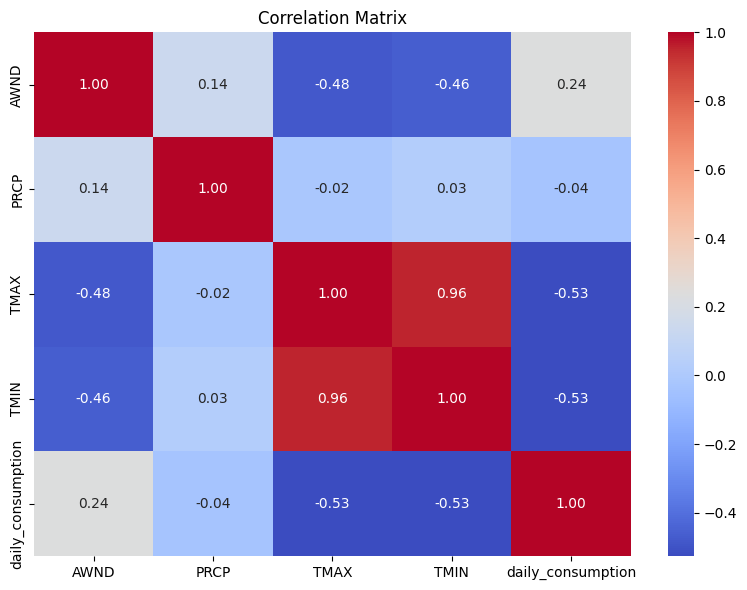

In [82]:
corr_matrix = data[['AWND', 'PRCP', 'TMAX', 'TMIN', 'daily_consumption']].corr(numeric_only=True)

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.tight_layout()

### Análisis de datos

Por lo visto en la matriz de correlación anterior, factores la temperatura tiene un impacto en el consumo de electricidad, y la precipitación tiene el menor impacto. La fluctuación en el valor de la temperatura mínima y máxima del día tendrá una gran influencia en el consumo de electricidad.

# Revisión de datos nulos / faltantes

<Axes: >

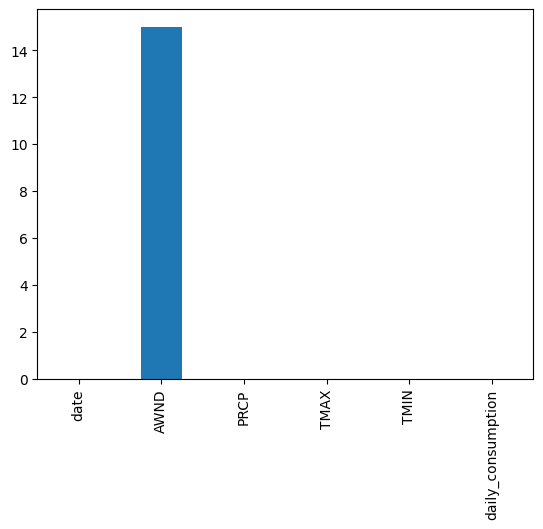

In [83]:
missing_counts = data.isnull().sum()
missing_counts.plot(kind='bar')

In [84]:
missing_percent = data.isnull().mean() * 100
missing_percent.sort_values(ascending=False)

,0
AWND,1.046755
date,0.000000
PRCP,0.000000
TMAX,0.000000
TMIN,0.000000
daily_consumption,0.000000


## Utilización de características relevantes

Utilizaremos todas las características excepto la fecha, ya que la cuestión de qué día fue no afecta en lo absoluto a las condiciones meteorológicas que pudieron haber influido en el consumo de electricidad.

Tras observar presencia de valores nulos en la característica de la velocidad del viento (AWND), utilizaremos la estrategia de un SimpleImputer para obtener el valor promedio e insertar esos valores en los lugares nulos. No se elimina ya que únicamente ~$1\%$ de los datos son ausentes.

# Pipeline de pre-procesamiento

Para trabajar con estos datos, aplicaremos un pipeline a la característica de AWND, como mencionado anteriormente.

In [85]:
preprocessing_pipeline = make_pipeline(
    ColumnTransformer(
        transformers=[
            ('wind', make_pipeline(SimpleImputer(strategy='mean'), StandardScaler()), ['AWND']),
        ],
        remainder='passthrough',
    )
)

# Partición en conjuntos de prueba y validación

In [86]:
x = data[numerical_cols]
y = data['daily_consumption']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [87]:
x_train_processed = preprocessing_pipeline.fit_transform(x_train, y_train)
x_train_processed

array([[ 1.03856526,  7.6       , 19.4       , 12.2       ],
       [-0.56524727,  0.        , 25.6       , 11.7       ],
       [ 0.23665899,  0.        , 17.8       , 10.6       ],
       ...,
       [-1.09985145,  0.        , 37.2       , 24.4       ],
       [-0.56524727,  0.        , 31.1       , 11.1       ],
       [ 0.        ,  1.3       , 10.        ,  2.8       ]])

In [88]:
x_test_processed = preprocessing_pipeline.transform(x_test)
x_test_processed

array([[ 1.03856526,  0.        ,  5.        ,  1.7       ],
       [-0.47614658, 15.        , 31.1       , 21.1       ],
       [-0.92165006,  0.        , 22.8       , 12.2       ],
       ...,
       [ 0.23665899,  0.        ,  9.4       ,  3.3       ],
       [-0.92165006, 16.8       , 28.9       , 18.3       ],
       [-0.38704588,  0.        , 11.1       ,  5.        ]])

# Modelo de regresión lineal

In [89]:
regression_model = make_pipeline(
    preprocessing_pipeline,
    LinearRegression()
)

In [90]:
regression_model

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('pipeline',
                 Pipeline(steps=[('columntransformer',
                                  ColumnTransformer(remainder='passthrough',
                                                    transformers=[('wind',
                                                                   Pipeline(steps=[('simpleimputer',
                                                                                    SimpleImputer()),
                                                                                   ('standardscaler',
                                                                                    StandardScaler())]),
                                                                   ['AWND'])]))])),
                ('linearregression', LinearRegression())])

In [91]:
regression_model.fit(x_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('pipeline',
                 Pipeline(steps=[('columntransformer',
                                  ColumnTransformer(remainder='passthrough',
                                                    transformers=[('wind',
                                                                   Pipeline(steps=[('simpleimputer',
                                                                                    SimpleImputer()),
                                                                                   ('standardscaler',
                                                                                    StandardScaler())]),
                                                                   ['AWND'])]))])),
                ('linearregression', LinearRegression())])

In [92]:
y_test_pred = regression_model.predict(x_test)
y_test_pred

array([1882.75549338, 1115.41511555, 1437.4276689 , 1207.55664001,
       1258.01397488, 1304.68879016, 1299.59390995, 2349.34086915,
       1490.39604724, 1440.74147192, 1642.47558436, 1471.76271329,
       1635.43635374, 2119.92944209, 1645.41233634, 1053.50088805,
       1754.91418153, 1121.97722813, 1708.25646499, 1846.2488611 ,
       1913.0635872 , 1199.13203905, 2042.54153204, 1223.42562308,
       1648.13724067, 2033.71277542, 1444.26557429, 1383.51623674,
       1475.09954402, 1653.45039122, 1227.1889704 , 1912.04707452,
       1921.96423165, 1541.93011918, 1708.62246426, 1738.66835509,
       1472.05382426, 1356.49863951, 2100.21831327, 1307.84636389,
       1407.3252365 , 1501.71980151, 2127.94056455, 2303.35069048,
       1611.01738307, 1778.5977186 , 1574.96219214, 1747.57241649,
       2045.70744134, 2043.73509081, 2075.36013851, 1785.66042787,
       1367.87346937, 1405.93789724, 1652.67981453, 1791.25608548,
       2059.07620614, 2007.57905216, 1060.01016306, 1385.29196

In [93]:
x_test['predicción_consumo'] = y_test_pred
x_test['consumo_actual'] = y_test.values
x_test

,PRCP,TMAX,TMIN,AWND,predicción_consumo,consumo_actual
370,0.0,5.0,1.7,3.8,1882.755493,2611.264
560,15.0,31.1,21.1,2.1,1115.415116,749.352
1007,0.0,22.8,12.2,1.6,1437.427669,2035.328
589,0.0,30.0,18.9,1.1,1207.556640,825.804
983,0.0,25.6,19.4,1.6,1258.013975,749.466
...,...,...,...,...,...,...
464,0.0,8.9,-0.6,3.6,1872.522879,2015.856
1375,27.9,23.9,20.6,NaN,1201.116709,1248.278
1124,0.0,9.4,3.3,2.9,1794.024062,2150.112
925,16.8,28.9,18.3,1.6,1200.696487,1192.446
